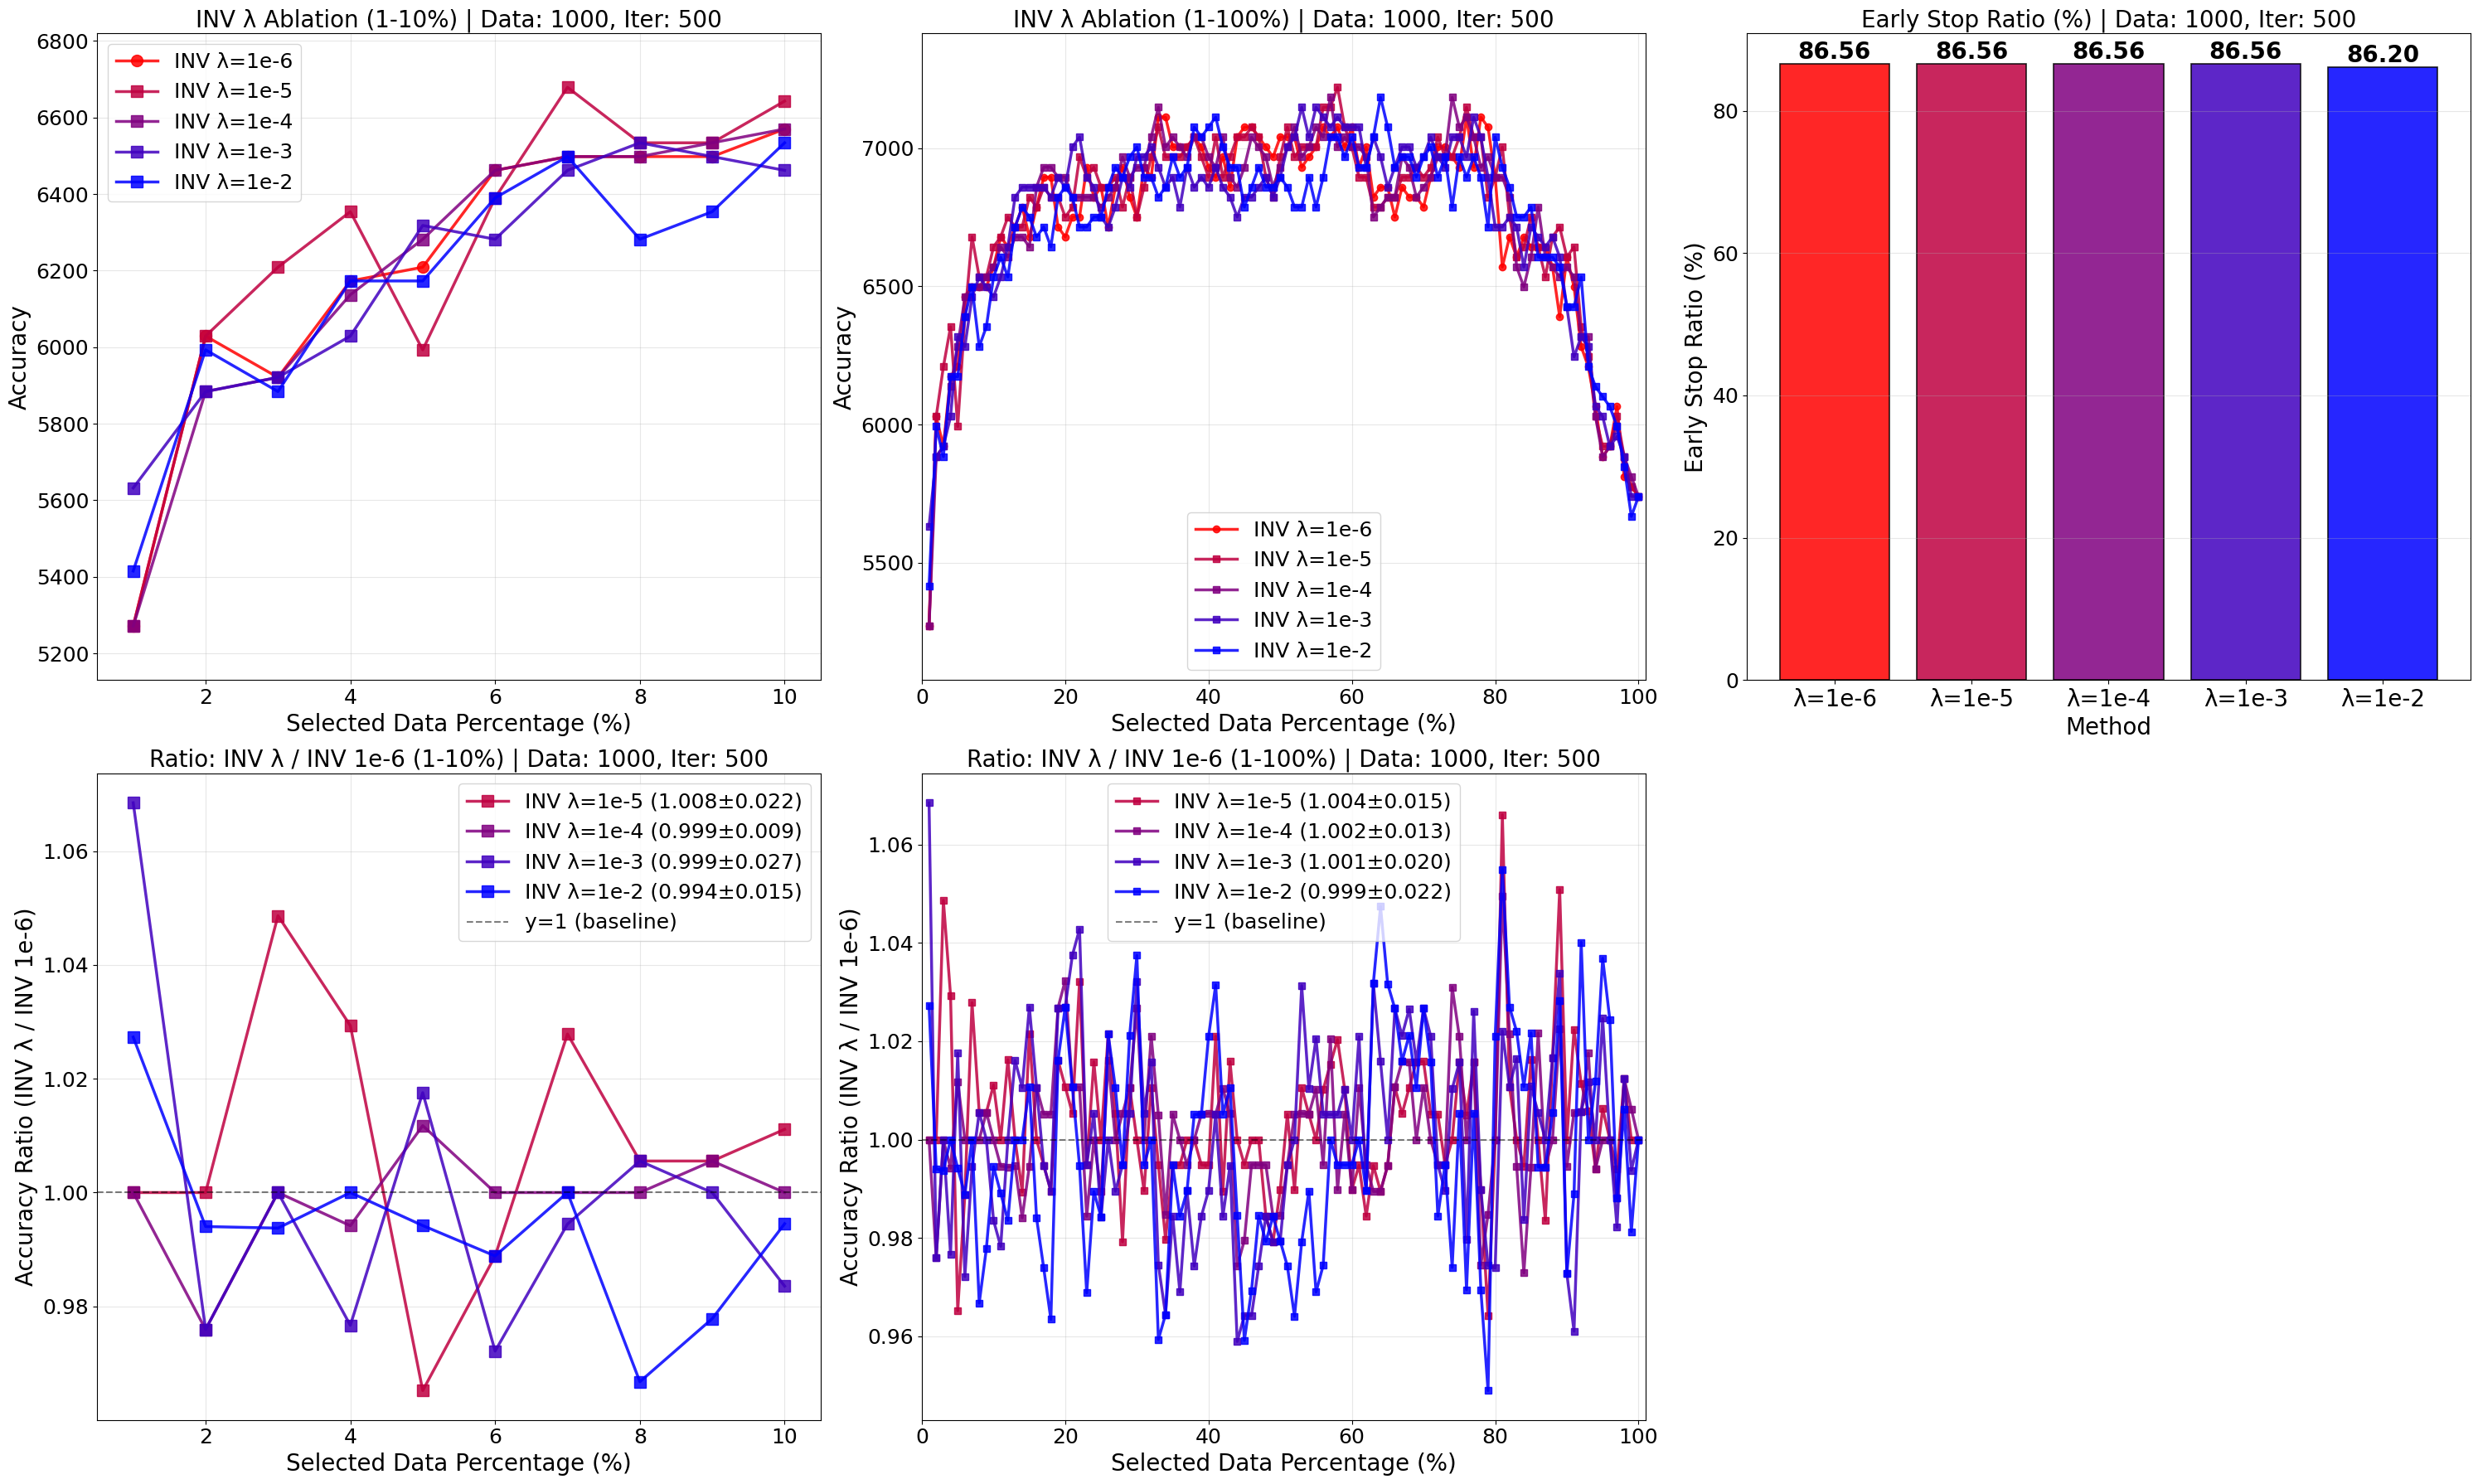

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 1000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [5271, 6029, 5921, 6173, 6209, 6462, 6498, 6498, 6498, 6570, 6679, 6643, 6715, 6787, 6679, 6787, 6895, 6895, 6715, 6679, 6751, 6751, 6931, 6823, 6859, 6715, 6859, 6931, 6823, 6751, 6931, 6895, 7112, 7112, 7004, 7004, 7004, 7040, 7004, 6931, 6895, 6968, 6859, 7040, 7076, 7076, 7040, 7004, 6968, 7040, 7040, 7040, 6931, 6968, 7004, 7076, 7040, 7076, 7004, 7076, 6931, 7004, 6823, 6859, 6859, 6751, 6859, 6823, 6823, 6787, 6895, 7004, 7004, 6968, 6931, 7112, 6931, 7112, 7076, 6895, 6570, 6679, 6606, 6679, 6643, 6643, 6643, 6570, 6390, 6606, 6498, 6282, 6209, 6065, 5884, 5921, 6065, 5812, 5776, 5740]
lam1e_5  = [5271, 6029, 6209, 6354, 5993, 6390, 6679, 6534, 6534, 6643, 6679, 6751, 6715, 6715, 6823, 6787, 6859, 6823, 6823, 6751, 6787, 6968, 6895, 6931, 6859, 6859, 6895, 6787, 6895, 6751, 6859, 6968, 7076, 6968, 6968, 6968, 7004, 7040, 6968, 6895, 7040, 6895, 6968, 7040, 7040, 7076, 7040, 6895, 6823, 6968, 7076, 6968, 7004, 7004, 7004, 7148, 7148, 7220, 7076, 7004, 6895, 6895, 6787, 6787, 6823, 6823, 6895, 6895, 6931, 6895, 6931, 7040, 6968, 6968, 7040, 7148, 7040, 7040, 6823, 6895, 7004, 6751, 6606, 6643, 6751, 6643, 6534, 6679, 6715, 6606, 6643, 6354, 6245, 6029, 5921, 5921, 6029, 5884, 5776, 5740]
lam1e_4  = [5271, 5884, 5921, 6137, 6282, 6462, 6498, 6498, 6534, 6570, 6643, 6606, 6679, 6679, 6643, 6859, 6931, 6931, 6895, 6895, 6823, 6823, 6823, 6823, 6787, 6823, 6859, 6968, 6895, 6931, 6931, 7040, 7148, 7004, 7040, 7004, 6968, 7040, 7040, 6968, 6931, 7040, 6895, 6859, 6931, 7040, 7004, 6968, 6859, 6931, 7004, 7076, 6968, 7004, 7076, 7040, 7184, 7004, 7040, 7004, 7004, 6968, 6751, 6787, 6823, 6823, 6968, 6931, 6823, 6859, 6895, 6968, 6968, 7184, 7076, 7112, 7040, 6931, 6968, 6895, 6895, 6823, 6570, 6498, 6606, 6787, 6606, 6570, 6534, 6570, 6534, 6318, 6318, 6029, 5884, 5921, 5993, 5884, 5812, 5740]
lam1e_3  = [5632, 5884, 5921, 6029, 6318, 6282, 6462, 6534, 6498, 6462, 6534, 6643, 6823, 6859, 6859, 6859, 6859, 6823, 6895, 6859, 7004, 7040, 6895, 6859, 6751, 6715, 6787, 6895, 6859, 6968, 6968, 7004, 6931, 6859, 6895, 6787, 6931, 6859, 6895, 6859, 6931, 6859, 6823, 6751, 6823, 6823, 6859, 6895, 6823, 6895, 7004, 7040, 7148, 7040, 7148, 7112, 7076, 7112, 7076, 7076, 7076, 6931, 7040, 6968, 6859, 6931, 7004, 7004, 6931, 6968, 7040, 6968, 6931, 7040, 7040, 6968, 7112, 7040, 6895, 6715, 6715, 6751, 6715, 6570, 6715, 6679, 6643, 6679, 6606, 6426, 6245, 6318, 6282, 6065, 6029, 5921, 5957, 5884, 5740, 5740]
lam1e_2  = [5415, 5993, 5884, 6173, 6173, 6390, 6498, 6282, 6354, 6534, 6606, 6534, 6715, 6787, 6751, 6679, 6715, 6643, 6823, 6859, 6823, 6715, 6715, 6751, 6751, 6859, 6931, 6895, 6968, 7004, 6895, 6895, 6823, 6859, 6968, 6895, 6931, 7076, 7040, 7076, 7112, 7004, 6931, 6931, 6787, 6859, 6931, 6859, 6859, 6895, 6859, 6787, 6787, 6895, 6787, 6895, 7040, 7040, 6968, 7040, 6931, 6931, 7040, 7184, 7076, 6931, 6968, 6968, 6895, 6968, 7004, 6895, 6968, 6787, 6968, 6895, 6968, 6895, 6715, 7040, 6931, 6859, 6751, 6751, 6787, 6606, 6606, 6606, 6570, 6426, 6426, 6534, 6209, 6137, 6101, 6065, 5993, 5848, 5668, 5740]

lam1e_6_early_stop = [86.56]
lam1e_5_early_stop = [86.56]
lam1e_4_early_stop = [86.56]
lam1e_3_early_stop = [86.56]
lam1e_2_early_stop = [86.20]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

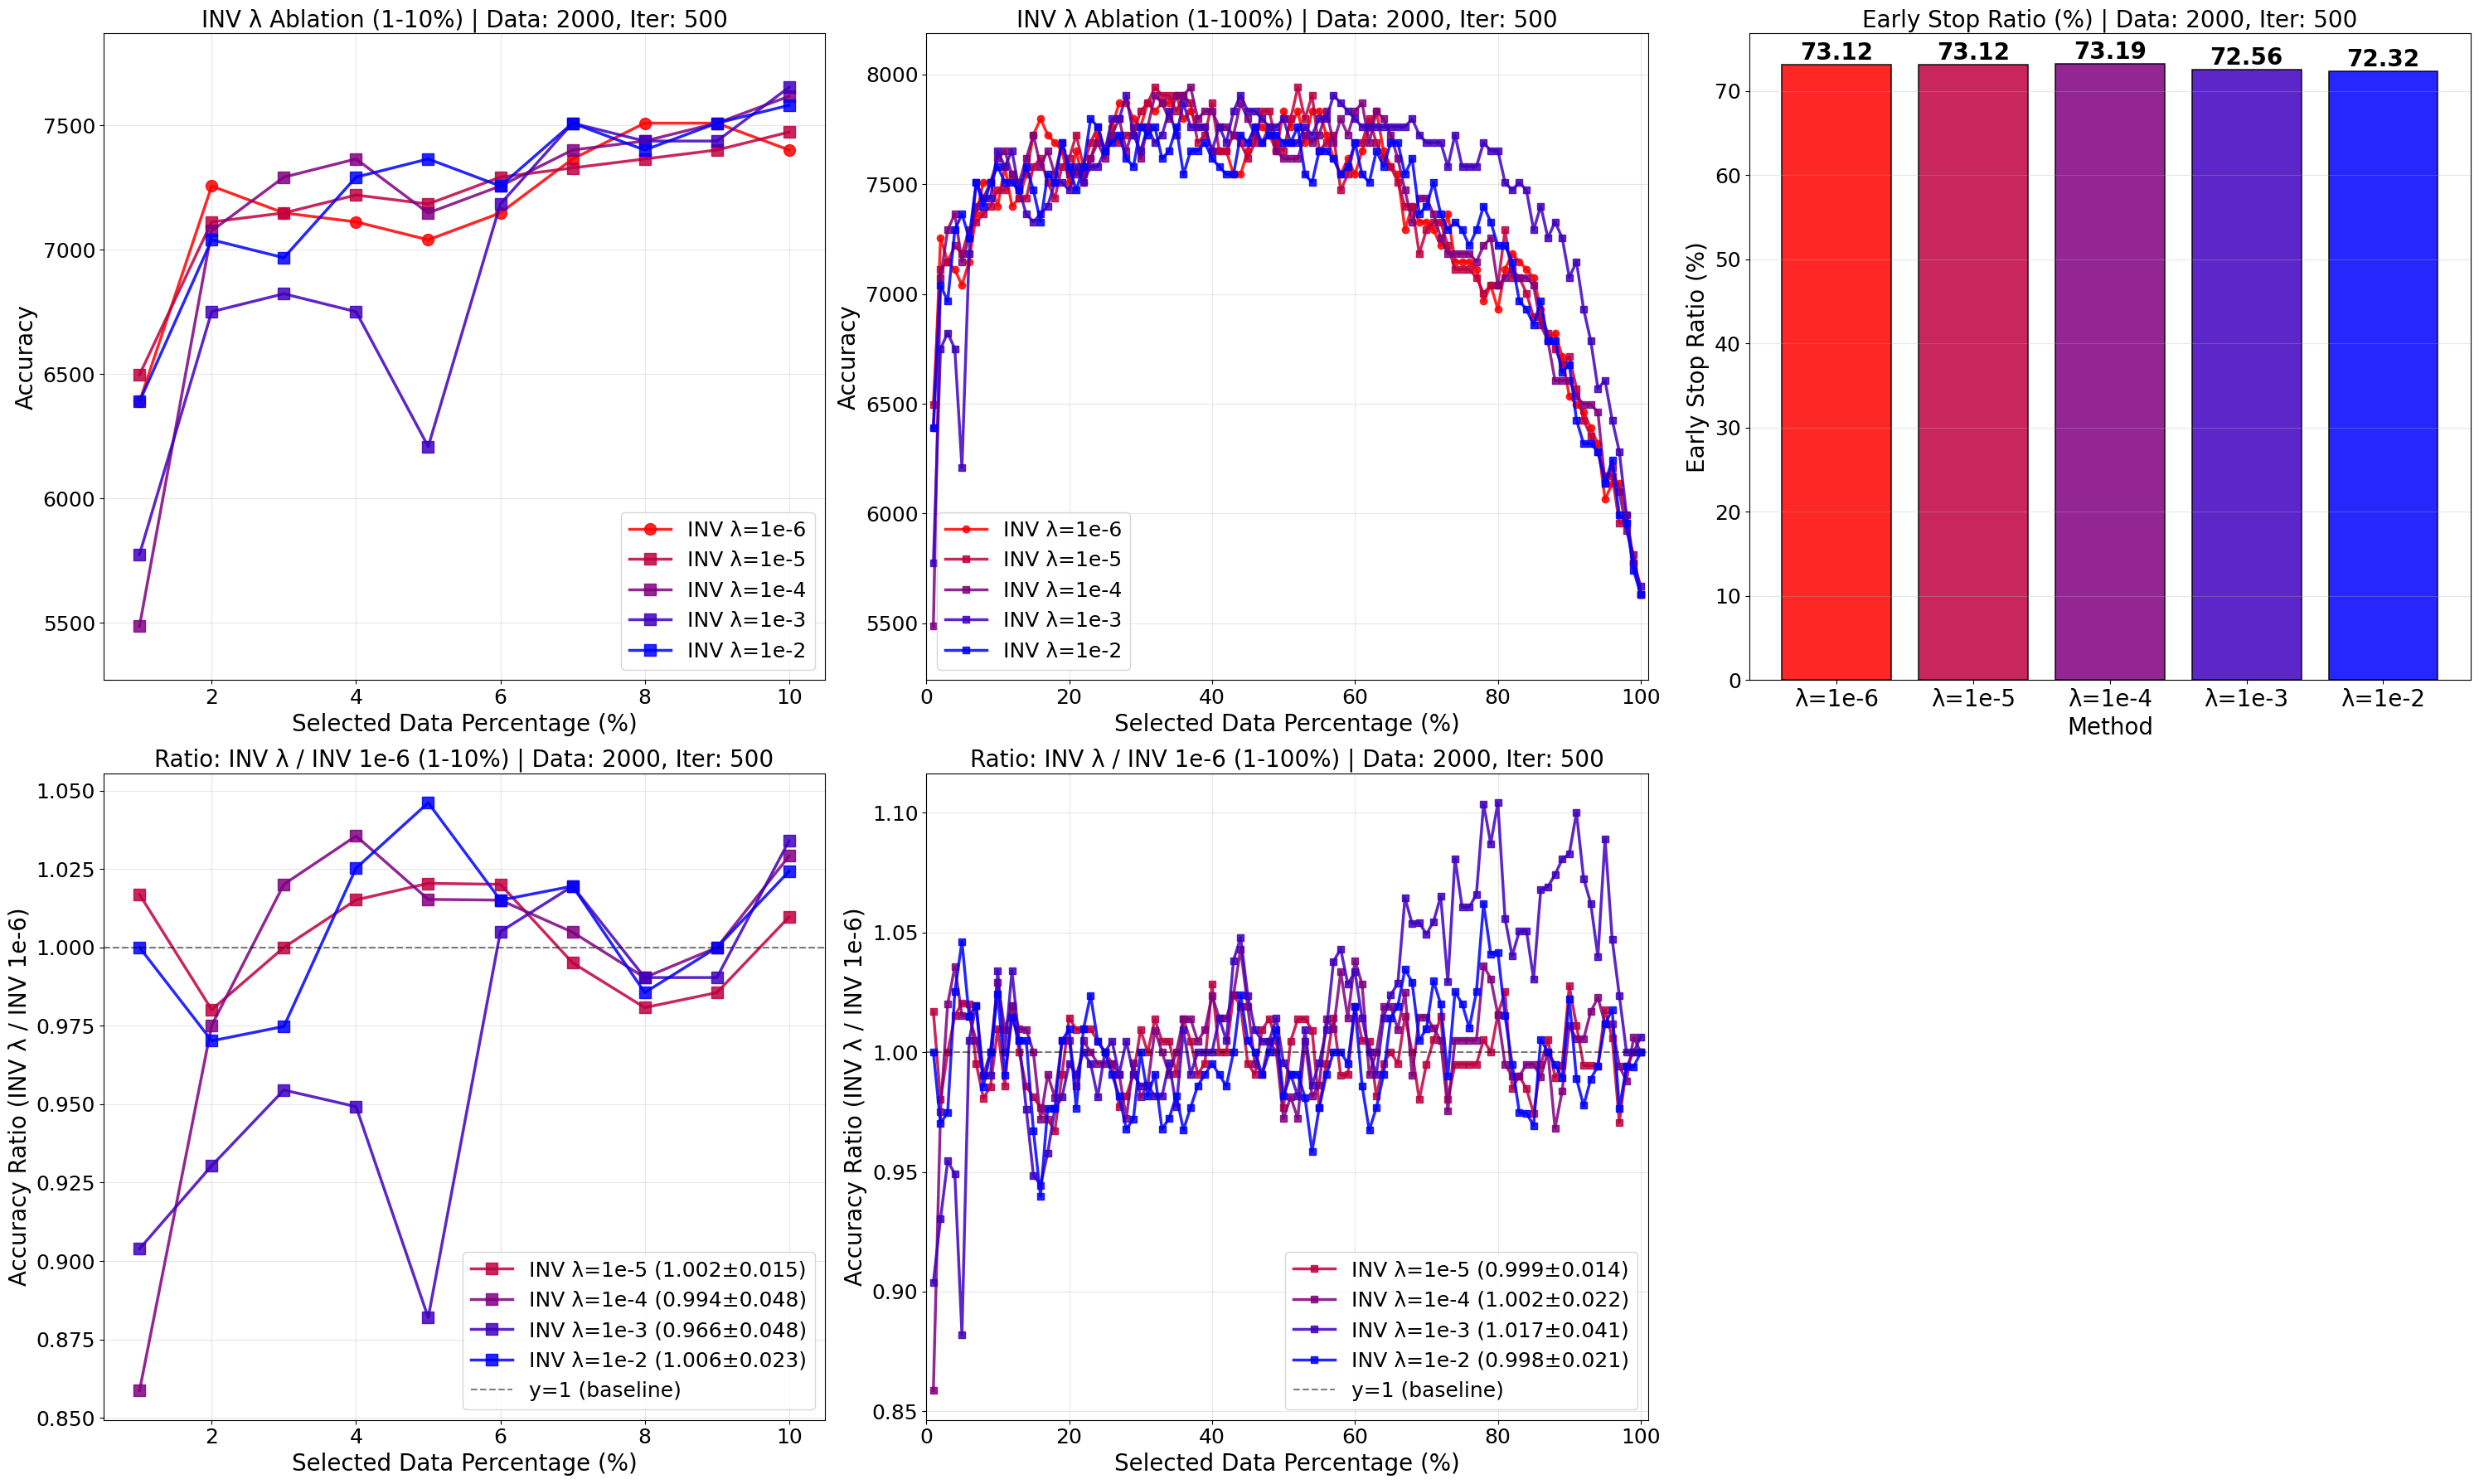

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 2000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [6390, 7256, 7148, 7112, 7040, 7148, 7365, 7509, 7509, 7401, 7581, 7401, 7437, 7545, 7726, 7798, 7726, 7690, 7653, 7509, 7653, 7509, 7617, 7726, 7653, 7762, 7870, 7870, 7798, 7762, 7870, 7834, 7870, 7870, 7906, 7798, 7834, 7762, 7762, 7653, 7653, 7653, 7545, 7545, 7653, 7762, 7762, 7726, 7653, 7834, 7762, 7834, 7690, 7834, 7834, 7726, 7617, 7545, 7617, 7545, 7653, 7762, 7834, 7653, 7581, 7545, 7292, 7401, 7329, 7329, 7292, 7220, 7365, 7148, 7148, 7148, 7112, 6968, 7040, 6931, 7112, 7184, 7148, 7112, 7076, 6931, 6787, 6823, 6715, 6534, 6498, 6462, 6390, 6318, 6065, 6137, 6137, 5993, 5776, 5632]
lam1e_5  = [6498, 7112, 7148, 7220, 7184, 7292, 7329, 7365, 7401, 7473, 7473, 7545, 7437, 7437, 7581, 7617, 7509, 7437, 7581, 7617, 7726, 7581, 7690, 7762, 7653, 7726, 7690, 7726, 7726, 7834, 7870, 7942, 7906, 7906, 7834, 7906, 7870, 7690, 7726, 7870, 7653, 7653, 7726, 7690, 7617, 7690, 7834, 7834, 7690, 7653, 7798, 7942, 7798, 7906, 7653, 7690, 7726, 7473, 7545, 7690, 7690, 7798, 7690, 7617, 7581, 7509, 7401, 7401, 7184, 7292, 7329, 7329, 7220, 7112, 7112, 7112, 7076, 7004, 7040, 7040, 7292, 7076, 7076, 7004, 6895, 6895, 6823, 6751, 6679, 6715, 6570, 6426, 6354, 6282, 6173, 6173, 5957, 5957, 5776, 5632]
lam1e_4  = [5487, 7076, 7292, 7365, 7148, 7256, 7401, 7437, 7509, 7617, 7653, 7545, 7509, 7617, 7726, 7581, 7653, 7545, 7690, 7545, 7545, 7545, 7617, 7690, 7617, 7726, 7798, 7653, 7762, 7617, 7762, 7906, 7870, 7798, 7906, 7906, 7942, 7798, 7834, 7834, 7762, 7762, 7726, 7870, 7798, 7726, 7690, 7762, 7653, 7617, 7617, 7617, 7726, 7690, 7726, 7834, 7690, 7798, 7726, 7834, 7870, 7690, 7834, 7798, 7726, 7617, 7473, 7329, 7437, 7437, 7365, 7256, 7184, 7184, 7184, 7184, 7148, 7220, 7256, 7040, 7076, 7112, 7076, 7076, 7040, 6859, 6787, 6606, 6606, 6606, 6534, 6498, 6498, 6462, 6137, 6209, 6101, 5921, 5812, 5632]
lam1e_3  = [5776, 6751, 6823, 6751, 6209, 7184, 7509, 7437, 7437, 7653, 7581, 7653, 7473, 7365, 7329, 7365, 7401, 7509, 7509, 7473, 7581, 7509, 7581, 7581, 7653, 7798, 7798, 7906, 7726, 7653, 7762, 7690, 7726, 7834, 7726, 7870, 7762, 7762, 7762, 7653, 7762, 7690, 7834, 7906, 7834, 7834, 7798, 7762, 7762, 7798, 7690, 7690, 7762, 7726, 7798, 7798, 7906, 7870, 7834, 7798, 7762, 7762, 7762, 7762, 7762, 7762, 7762, 7798, 7726, 7690, 7690, 7690, 7581, 7726, 7581, 7581, 7581, 7690, 7653, 7653, 7509, 7473, 7509, 7473, 7292, 7401, 7256, 7329, 7256, 7076, 7148, 6931, 6787, 6570, 6606, 6426, 6282, 5993, 5776, 5668]
lam1e_2  = [6390, 7040, 6968, 7292, 7365, 7256, 7509, 7401, 7509, 7581, 7509, 7509, 7473, 7581, 7473, 7329, 7545, 7509, 7690, 7581, 7473, 7581, 7798, 7762, 7653, 7690, 7726, 7617, 7581, 7762, 7726, 7762, 7617, 7653, 7762, 7545, 7653, 7653, 7690, 7617, 7581, 7545, 7545, 7726, 7690, 7762, 7690, 7726, 7726, 7690, 7690, 7762, 7545, 7509, 7653, 7653, 7617, 7545, 7581, 7690, 7545, 7509, 7653, 7581, 7690, 7690, 7545, 7617, 7365, 7401, 7509, 7365, 7292, 7329, 7292, 7220, 7292, 7401, 7329, 7220, 7220, 7148, 6968, 6931, 6859, 6968, 6787, 6787, 6643, 6679, 6426, 6318, 6318, 6282, 6137, 6245, 5993, 5957, 5740, 5632]

lam1e_6_early_stop = [73.12]
lam1e_5_early_stop = [73.12]
lam1e_4_early_stop = [73.19]
lam1e_3_early_stop = [72.56]
lam1e_2_early_stop = [72.32]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

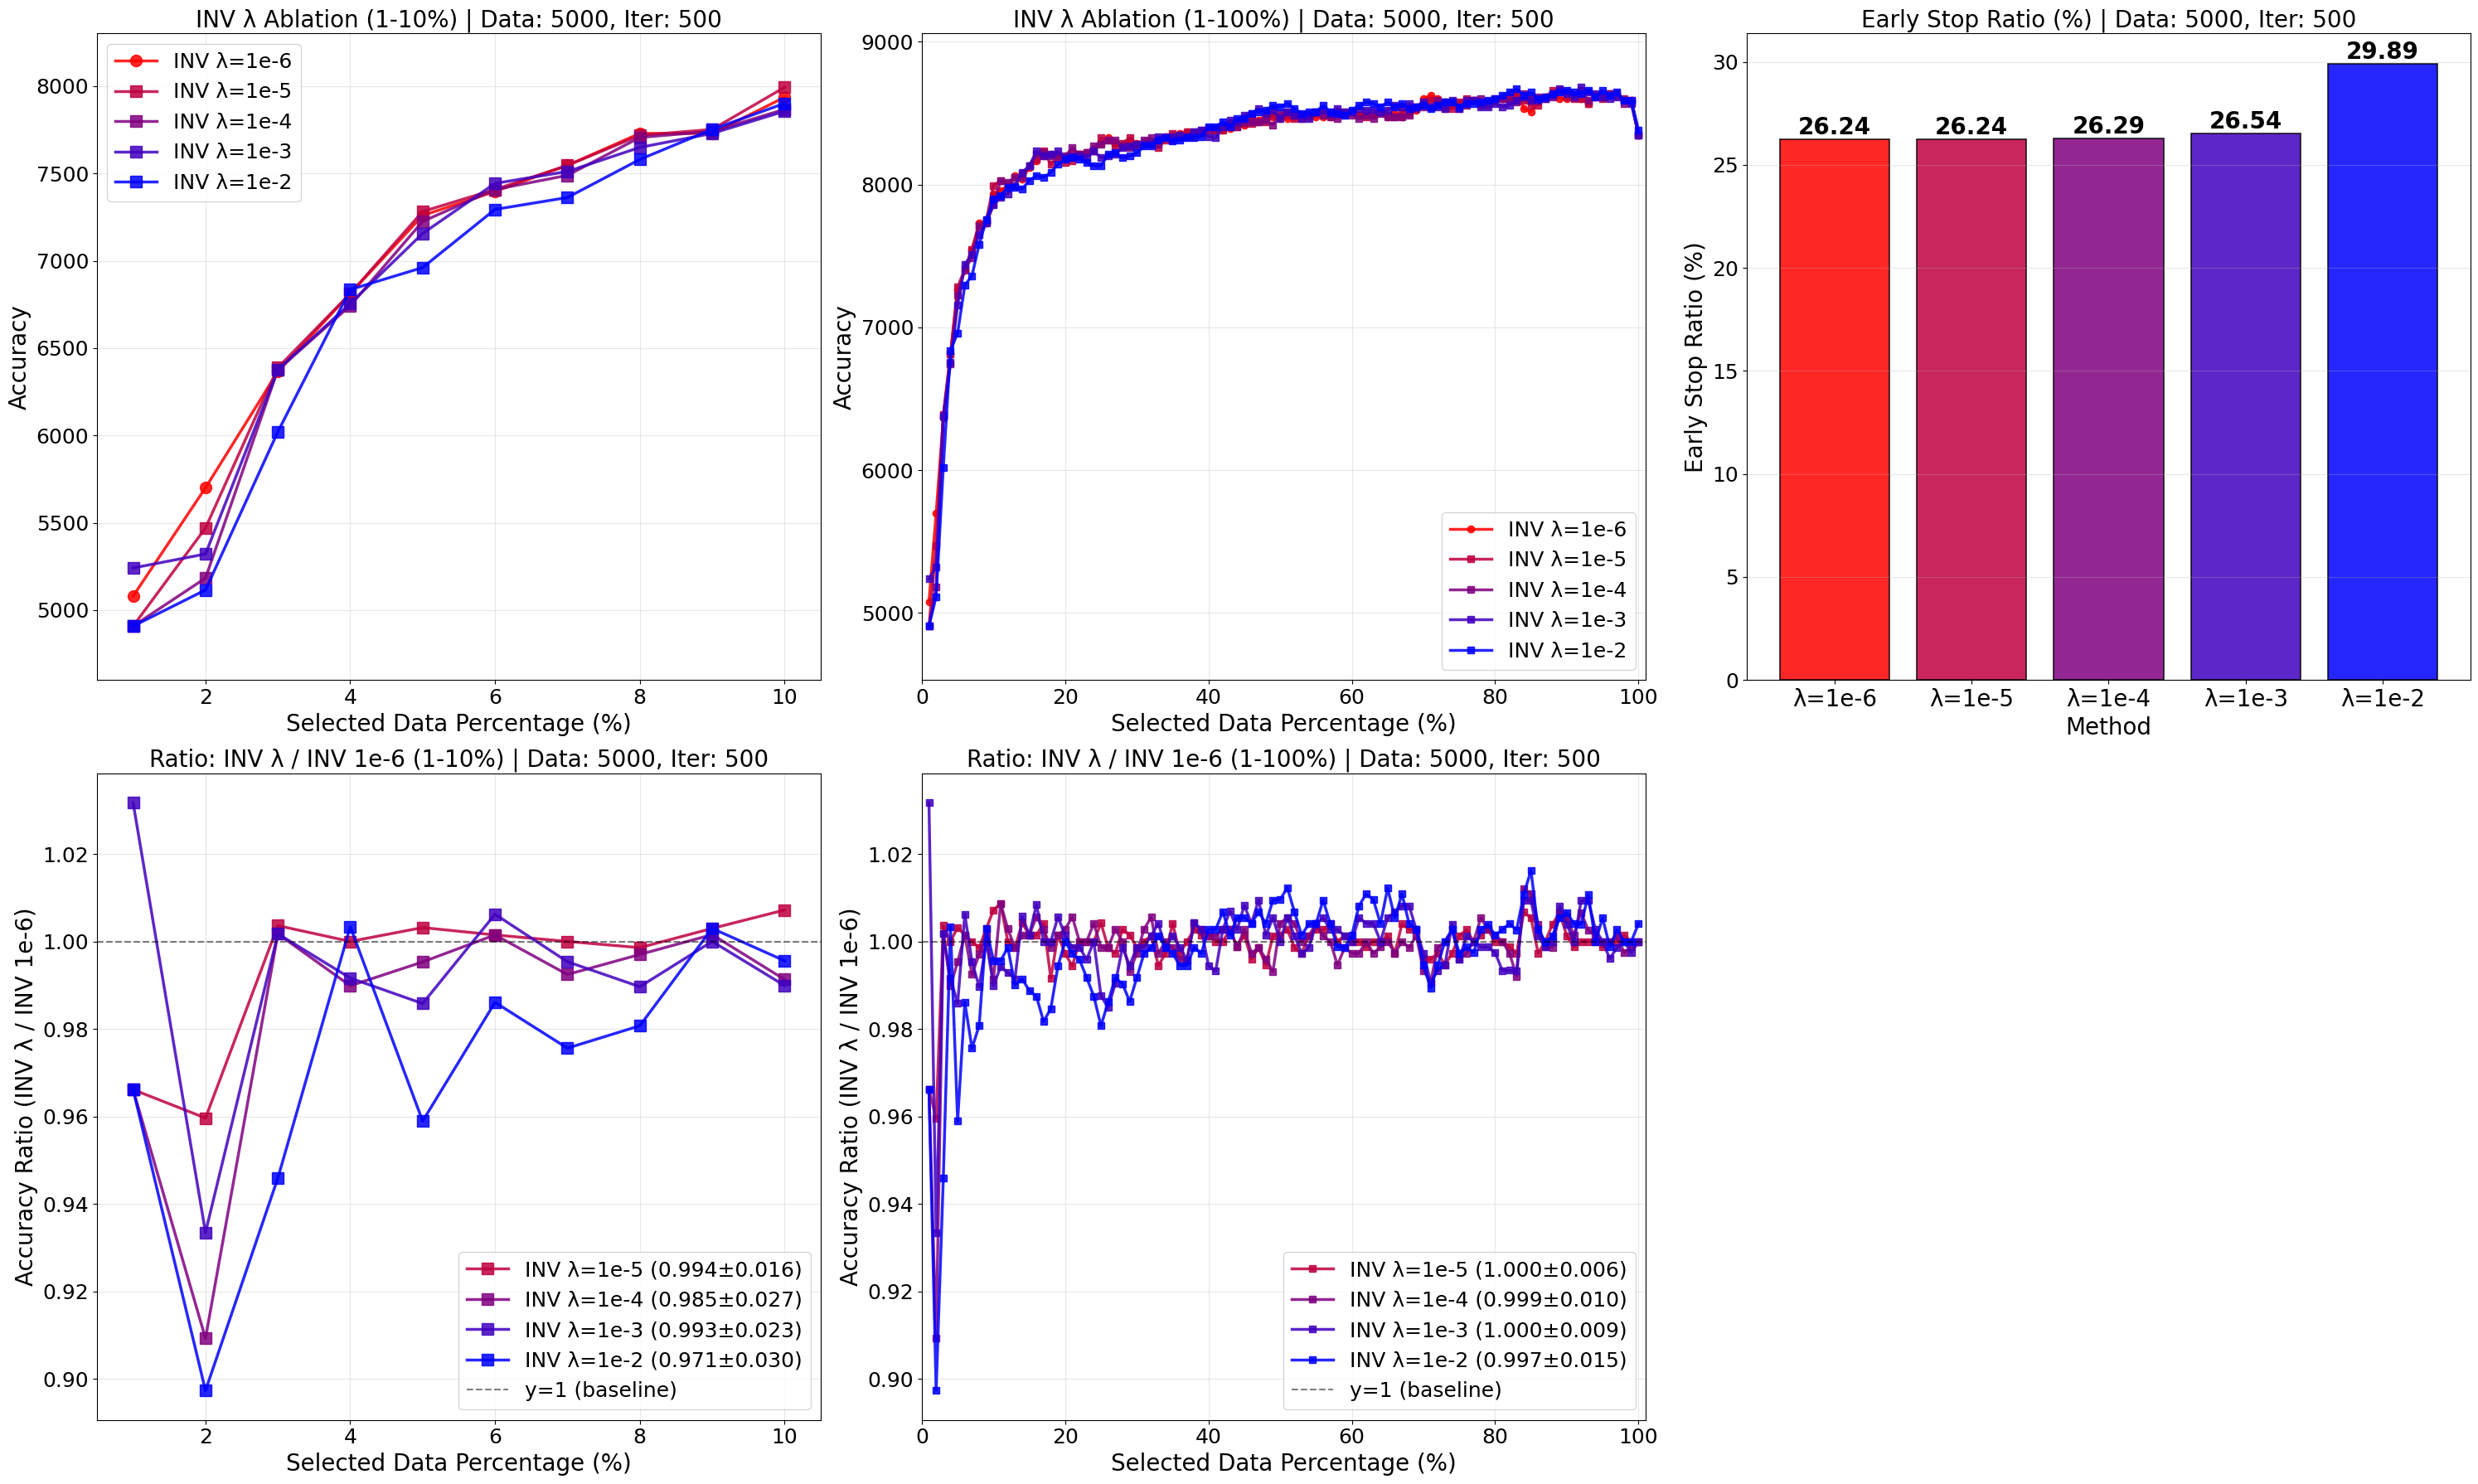

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 5000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 10000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()